## Библиотеки и константы


In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import scipy.stats as stats
import pylab
import struct
import json
import os
from IPython.display import clear_output
from math import factorial
from collections import defaultdict
from itertools import product, combinations, permutations
import inspect
import time

%matplotlib inline

In [2]:

ARTIFACT_FORMAT = "<10i"
ARTIFACT_SIZE = struct.calcsize(ARTIFACT_FORMAT)

### Базовые значения

In [3]:
stats_map = {
    "HP%": 0,
    "HP": 1, 
    "ATK%": 2,
    "ATK": 3,
    "DEF%": 4,
    "DEF": 5,
    "PEN": 6,
    "AP": 7, # Anomaly Proficiency
    "CRIT_RATE": 8,
    "CRIT_DMG": 9,
    "PEN%": 10,
    "AM": 11,
    "Impact": 12,
    "ER": 13,
    "Physical Bonus": 14,
    "Fire Bonus": 15,
    "Ice Bonus": 16,
    "Electric Bonus": 17,
    "Ether Bonus": 18,
    "Wind Bonus": 19,
    "None": 100,
}

stat_names = [""] * (max(stats_map.values()) + 1)
for name, stat_id in stats_map.items():
    if stat_id >= 0:
        stat_names[stat_id] = name

main_stat_values_map = {
    stats_map["HP%"]: 3000,
    stats_map["HP"]: 2200, 
    stats_map["ATK%"]: 3000,
    stats_map["ATK"]: 316,
    stats_map["DEF%"]: 4800,
    stats_map["DEF"]: 184, 
    stats_map["AP"]: 92,
    stats_map["CRIT_RATE"]: 2400,
    stats_map["CRIT_DMG"]: 4800,
    stats_map["PEN%"]: 2400,
    stats_map["Physical Bonus"]: 3000, # same for all elements
    stats_map["AM"]: 3000,
    stats_map["ER"]: 6000,
    stats_map["Impact"]: 1800
}

base_sub_stats_choices = np.array([
    stats_map["HP%"],
    stats_map["HP"], 
    stats_map["ATK%"],
    stats_map["ATK"],
    stats_map["DEF%"],
    stats_map["DEF"],
    stats_map["PEN"],
    stats_map["AP"],
    stats_map["CRIT_RATE"],
    stats_map["CRIT_DMG"]
], dtype=np.int32)

# 100%, 90%, 80%, 70%
sub_stat_values = np.array([
    300, # HP%
    112, # HP
    300, # ATK%
    19, # ATK
    480, # DEF%
    15, # DEF
    9, # PEN
    9, # AP
    240, # CRIT_RATE
    480, # CRIT_DMG
              
], dtype=np.int32)

sub_stats_weights = np.array([
    113, # HP%
    103, # HP
    90, # ATK%
    98, # ATK
    131, # DEF%
    112, # DEF
    107, # PEN
    97, # AP
    116, # CRIT_RATE
    104, # CRIT_DMG
              
], dtype=np.int32)

enka_stat_map = {
    11102: stats_map["HP%"],
    11103: stats_map["HP"], 
    12102: stats_map["ATK%"],
    12103: stats_map["ATK"],
    13102: stats_map["DEF%"],
    13103: stats_map["DEF"], 
    31203: stats_map["AP"],
    20103: stats_map["CRIT_RATE"],
    21103: stats_map["CRIT_DMG"],
    23103: stats_map["PEN%"],
    23203: stats_map["PEN"],
    31503: stats_map["Physical Bonus"],
    31603: stats_map["Fire Bonus"],
    31703: stats_map["Ice Bonus"],
    31803: stats_map["Electric Bonus"],
    31903: stats_map["Ether Bonus"],
    32303: stats_map["Wind Bonus"],
    31402: stats_map["AM"],
    30502: stats_map["ER"],
    12202: stats_map["Impact"]
}

BASE_STAT_IDS = {
    11101: "HP",
    12101: "ATK",
    13101: "DEF"
}

file_names = {'HP%', 'HP', 'ATK%', 'ATK', 'DEF%', 'DEF', 'AP', "CRIT_RATE", "CRIT_DMG"}

profit_names = {name: 0.0 for name in stat_names[:10]}

In [4]:
slot_1_pop = [stats_map["HP"]]
slot_1_prob = np.array([1], dtype=float)

slot_2_pop = [stats_map["ATK"]]
slot_2_prob = np.array([1], dtype=float)

slot_3_pop = [stats_map["DEF"]]
slot_3_prob = np.array([1], dtype=float)

slot_4_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["CRIT_RATE"],
    stats_map["CRIT_DMG"],
    stats_map["AP"]
]
slot_4_prob = np.array([1, 1, 1, 1, 1, 1], dtype=float)
slot_4_prob /= slot_4_prob.sum()

slot_5_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["PEN%"],
    stats_map["Physical Bonus"],
    stats_map["Fire Bonus"],
    stats_map["Ice Bonus"],
    stats_map["Electric Bonus"],
    stats_map["Ether Bonus"],
    stats_map["Wind Bonus"]
]
slot_5_prob = np.array([2, 2, 2, 1, 1, 1, 1, 1, 1], dtype=float)
slot_5_prob /= slot_5_prob.sum()


slot_6_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["AM"],
    stats_map["ER"],
    stats_map["Impact"]
]
slot_6_prob = np.array([2, 2, 2, 2, 2, 1], dtype=float)
slot_6_prob /= slot_6_prob.sum()


slots_prob = {
    1: (slot_1_pop, slot_1_prob),
    2: (slot_2_pop, slot_2_prob),
    3: (slot_3_pop, slot_3_prob),
    4: (slot_4_pop, slot_4_prob),
    5: (slot_5_pop, slot_5_prob),
    6: (slot_6_pop, slot_6_prob),
}



In [5]:
disc_cache = {}


def load_discs(main_stat):
    if main_stat >= 10:
        main_stat = 100
    if main_stat not in disc_cache:
        data = np.load(f"discs/{stat_names[main_stat]}.npz")

        disc_cache[main_stat] = (
            data["substats"],
            data["probabilities"]
        )

    return disc_cache[main_stat]

### Функции

In [6]:
def get_2_best_stat(main_stat, profit_order):
    best_stats = [
        stat for stat in profit_order
        if stat != main_stat
    ][:2]

    return best_stats[0], best_stats[1]

def get_disc_score(disc, profit, profit_order):
    main_stat = disc["main_stat"]["id"]
    slot = disc["slot"]
    best_stat_1, best_stat_2 = get_2_best_stat(main_stat, profit_order)
    main_stat_pop, main_stat_prob = slots_prob[slot]
    idx = main_stat_pop.index(main_stat)

    all_substats, probabilities = load_discs(main_stat)

    current_utility = np.dot(
        disc["substats"],
        profit
    )

    all_utilities = all_substats @ profit
    better = all_utilities > current_utility
    p_better = probabilities[better].sum()
    
    disc["craft_main_probability"] =  round(p_better, 6)
    disc["score"] = round((1 - p_better * main_stat_prob[idx]) * 100, 4)
    
    selected_1 = (
        all_substats[:, best_stat_1] > 0
    )

    selected_2 = (
        selected_1
        & (all_substats[:, best_stat_2] > 0)
    )
    
    disc["craft_one_probability"] = round(
        probabilities[better & selected_1].sum()
        / probabilities[selected_1].sum()
    , 6)

    disc["craft_two_probability"] = round(
        probabilities[better & selected_2].sum()
        / probabilities[selected_2].sum()
    , 6)


def evaluate_characters(uid):
    file_path = f"characters/{uid}.json"

    with open(file_path, "r", encoding="utf-8") as file:
        characters = json.load(file)

    for character in characters.values():
        if character["score"] > 1:
            continue
        profit = np.array(character["profit"])
        profit_order = np.argsort(profit)[::-1]

        total_score = 0

        for disc in character["discs"]:
            get_disc_score(disc, profit, profit_order)
            total_score += disc["score"]

        character["score"] = round(total_score, 2)

    with open(file_path, "w", encoding="utf-8") as file:
        json.dump(
            characters,
            file,
            ensure_ascii=False,
            indent=4
        )
        
    values = characters.values()

    return sorted(
        values,
        key=lambda character: character["score"]
    )
        

In [18]:
def plot_character_discs(characters):
    min_disc_score = min(
        disc["score"]
        for character in characters
        for disc in character["discs"]
    )

    # Небольшой отступ снизу
    y_min = max(0, min_disc_score * 0.9)

    for character in characters:
        discs = sorted(
            character["discs"],
            key=lambda disc: disc["slot"]
        )

        name = character["name_ru"]
        slots = [disc["slot"] for disc in discs]
        scores = [disc["score"] for disc in discs]

        plt.figure(figsize=(9, 5))

        bars = plt.bar(slots, scores)

        for bar, score in zip(bars, scores):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                score + 1,
                f"{score:.1f}",
                ha="center"
            )

        plt.ylim(y_min, 105)

        plt.xlabel("Слот диска")
        plt.ylabel("Оценка")
        plt.title(
            f"{name} — диски "
            f"(общая оценка {character['score']:.1f})"
        )

        plt.tight_layout()
        plt.show()
    
def plot_characters(characters):
    characters = characters[::-1]
    names = [character["name_ru"] for character in characters]
    scores = [
        character["score"]
        for character in characters
    ]

    plt.figure(figsize=(12, len(names) / 3.5))

    bars = plt.barh(names, scores)

    for bar, score in zip(bars, scores):
        plt.text(
            score + 2,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.1f}",
            va="center"
        )

    plt.xlim(0, 630)
    plt.xlabel("Суммарная оценка дисков")
    plt.title("Оценка персонажей")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()
    
def print_discs_by_character(characters):
    print(
        f"{'Character':15} {'Slot':>5} "
        f"{'Score':>8} | "
        f"{'Main':>9} {'Select 1':>9} {'Select 2':>9} | "
        f"Main stat"
    )
    print("-" * 85)

    for character in characters:
        name = character["name_ru"]

        print(
            f"{name:15} {'Total':>4} "
            f"{character['score']:8.2f} |"
        )

        discs = sorted(
            character["discs"],
            key=lambda disc: disc["slot"]
        )

        for disc in discs:
            print(
                f"{name:15} "
                f"{disc['slot']:>5} "
                f"{disc['score']:8.2f} | "
                f"{disc['craft_main_probability'] * 100:8.2f}% "
                f"{disc['craft_one_probability'] * 100:8.2f}% "
                f"{disc['craft_two_probability'] * 100:8.2f}% | "
                f"{disc['main_stat']['name']}"
            )

        print("-" * 85)
        
def print_discs_by_score(characters):
    all_discs = [
        (disc, character["name_ru"])
        for character in characters
        for disc in character["discs"]
    ]

    all_discs.sort(
        key=lambda x: x[0]["score"]
    )

    print(
        f"{'Character':15} {'Slot':>4} "
        f"{'Score':>8} | "
        f"{'Main':>9} {'Select 1':>9} {'Select 2':>9} | "
        f"Main stat"
    )
    print("-" * 85)

    for disc, name in all_discs:
        print(
            f"{name:15} "
            f"{disc['slot']:>4} "
            f"{disc['score']:8.2f} | "
            f"{disc['craft_main_probability'] * 100:8.2f}% "
            f"{disc['craft_one_probability'] * 100:8.2f}% "
            f"{disc['craft_two_probability'] * 100:8.2f}% | "
            f"{disc['main_stat']['name']}"
        )

In [8]:
uid = 1500018666
start_time = time.time()
characters = evaluate_characters(uid)

end_time = time.time()
print(f"--- {end_time - start_time} seconds of all disks ---")

--- 0.07701778411865234 seconds of all disks ---


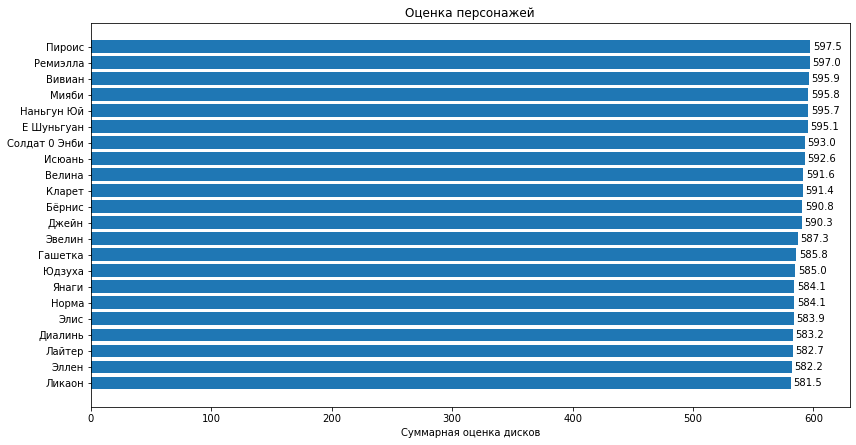

In [9]:
plot_characters(characters)

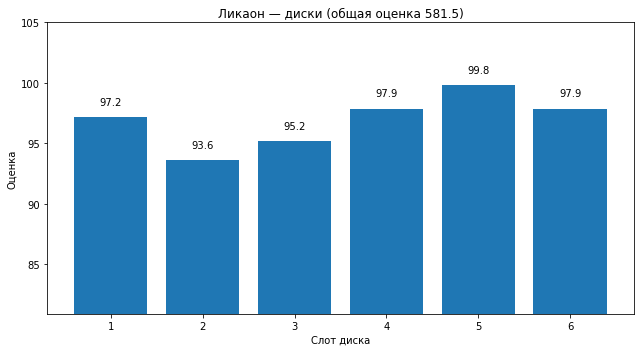

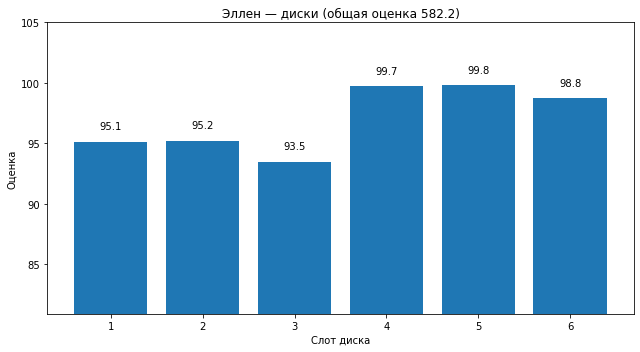

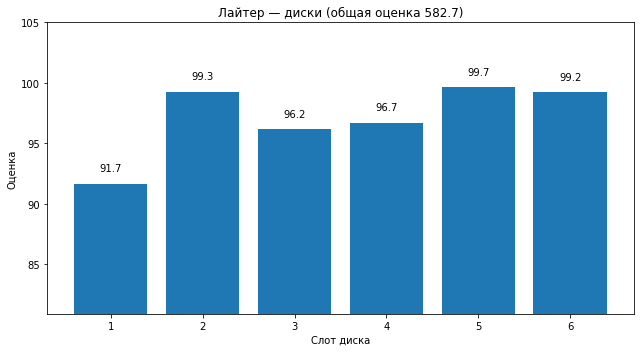

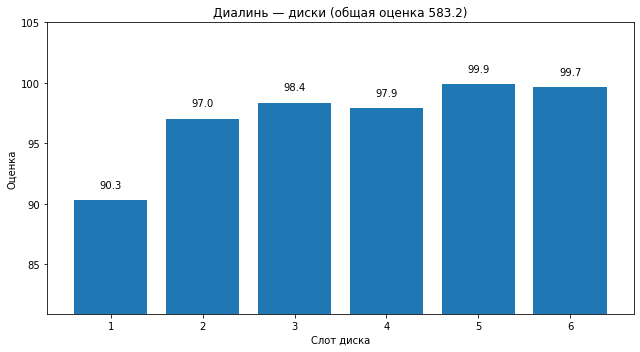

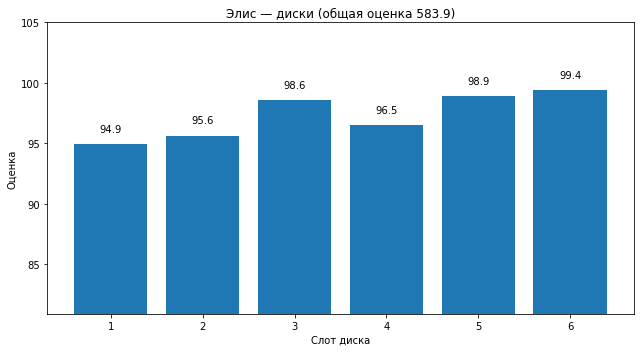

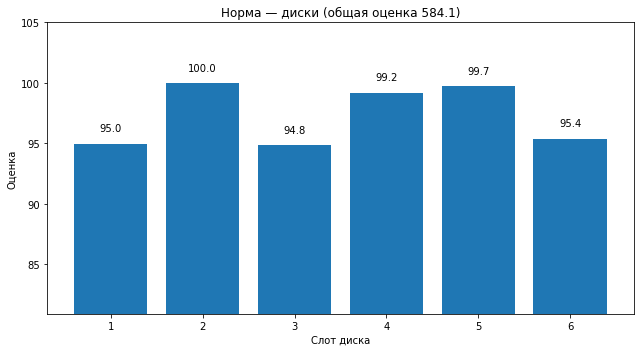

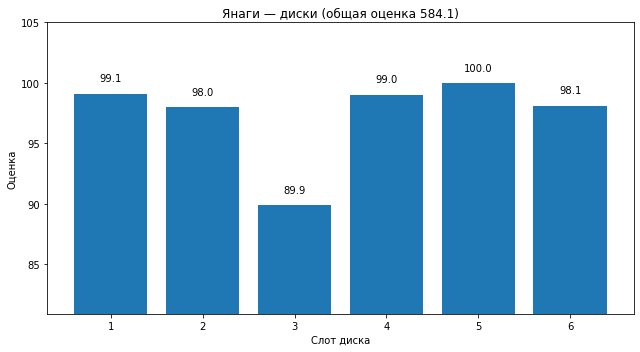

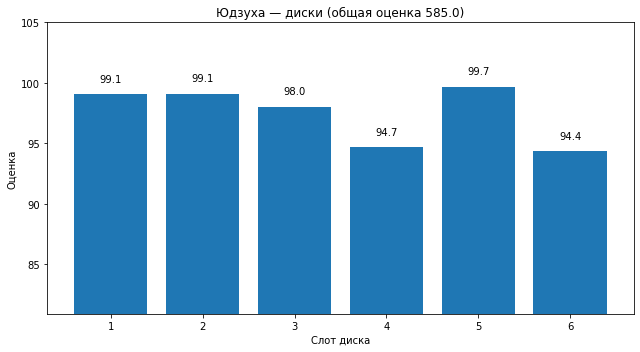

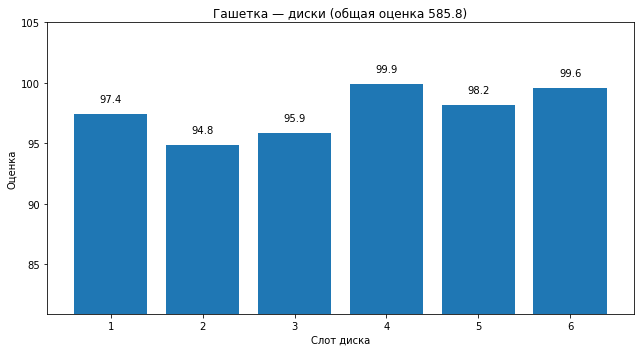

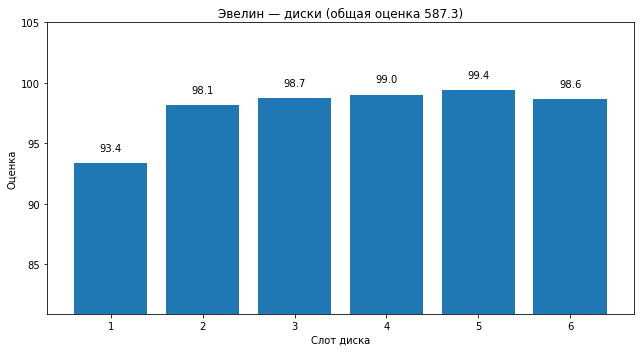

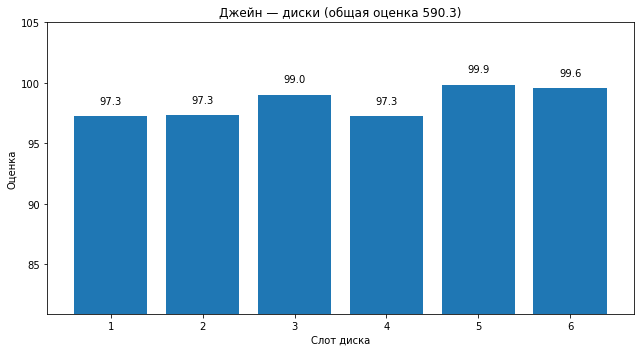

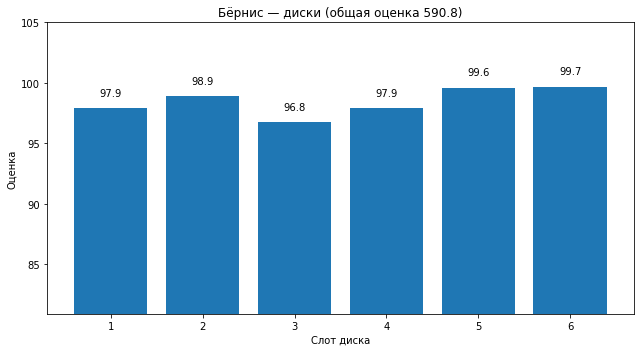

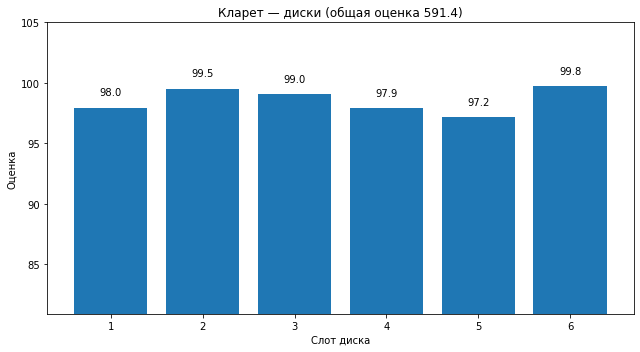

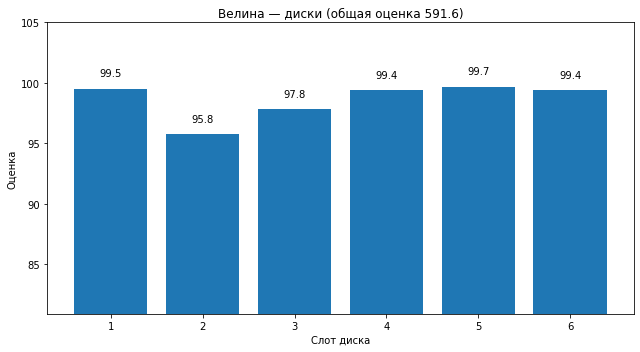

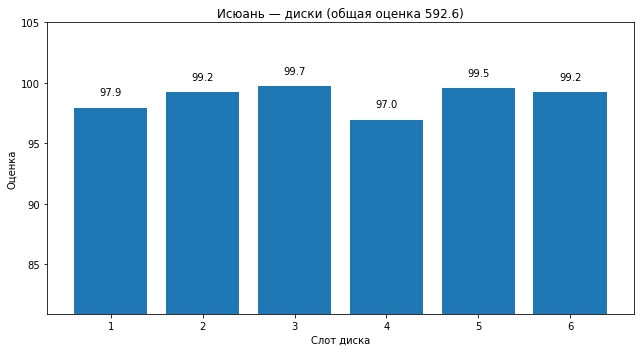

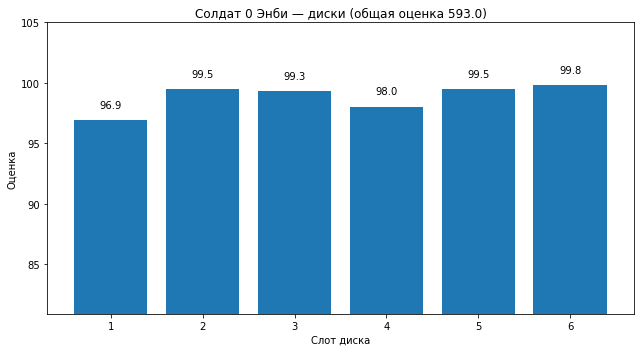

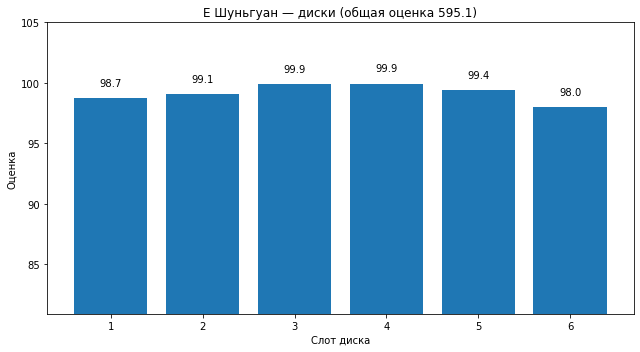

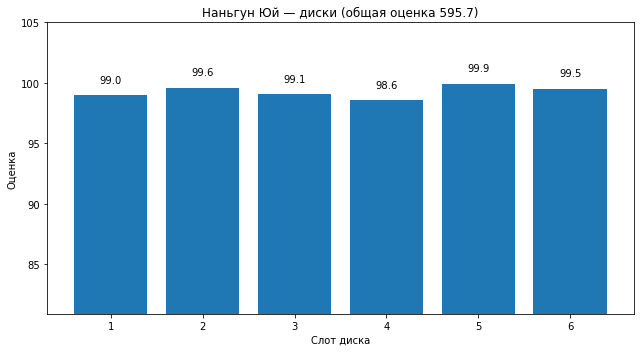

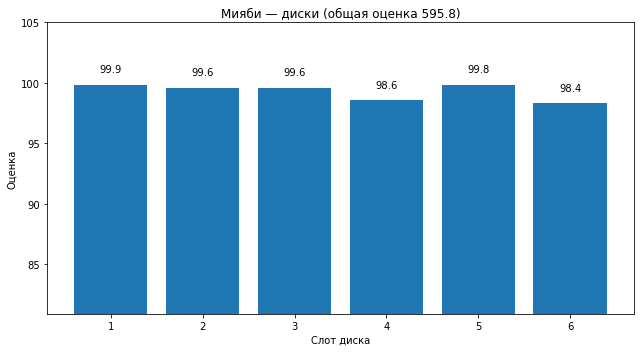

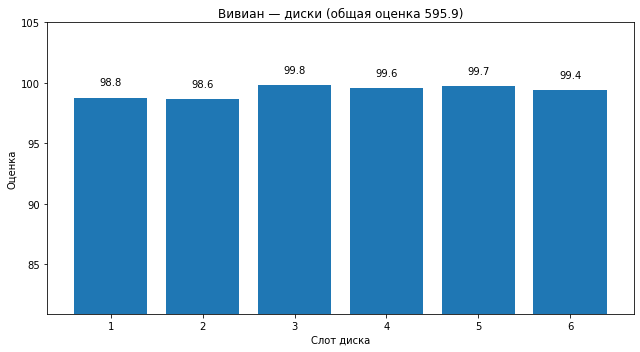

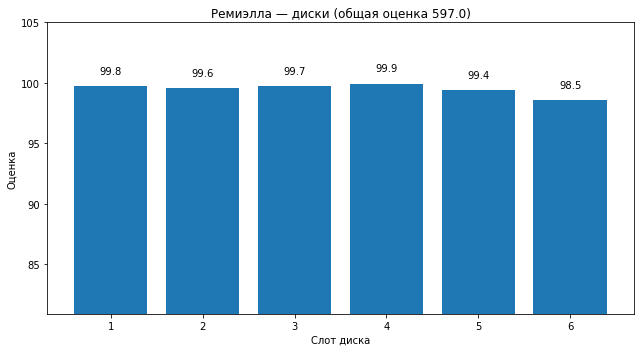

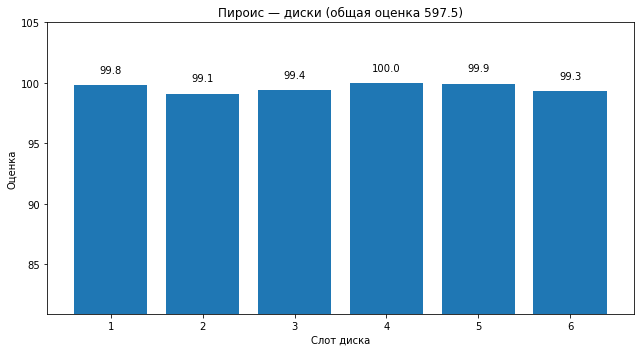

In [19]:
plot_character_discs(characters)

In [14]:
print_discs_by_character(characters)

Character        Slot    Score |      Main  Select 1  Select 2 | Main stat
-------------------------------------------------------------------------------------
Ликаон          Total   581.54 |
Ликаон              1    97.18 |     2.82%     5.94%    13.65% | HP
Ликаон              2    93.59 |     6.41%    12.45%    26.08% | ATK
Ликаон              3    95.20 |     4.80%     9.07%    18.39% | DEF
Ликаон              4    97.88 |    12.74%    24.31%    57.73% | CRIT_RATE
Ликаон              5    99.82 |     1.06%     2.43%     6.11% | ATK%
Ликаон              6    97.86 |    23.57%    39.26%    65.98% | Impact
-------------------------------------------------------------------------------------
Эллен           Total   582.16 |
Эллен               1    95.13 |     4.87%     9.21%    18.72% | HP
Эллен               2    95.23 |     4.77%     8.89%    17.67% | ATK
Эллен               3    93.48 |     6.52%    11.81%    22.65% | DEF
Эллен               4    99.74 |     1.57%     3.30%    10

In [15]:
print_discs_by_score(characters)

Character       Slot    Score |      Main  Select 1  Select 2 | Main stat
-------------------------------------------------------------------------------------
Янаги              3    89.88 |    10.12%    24.15%    51.79% | DEF
Диалинь            1    90.30 |     9.70%    22.42%    41.88% | HP
Лайтер             1    91.67 |     8.33%    17.03%    37.85% | HP
Эвелин             1    93.38 |     6.62%    13.49%    29.91% | HP
Эллен              3    93.48 |     6.52%    11.81%    22.65% | DEF
Ликаон             2    93.59 |     6.41%    12.45%    26.08% | ATK
Юдзуха             6    94.38 |    30.93%    55.86%    90.87% | AM
Юдзуха             4    94.71 |    31.77%    71.76%    90.13% | ATK%
Норма              3    94.83 |     5.17%     9.74%    19.64% | DEF
Гашетка            2    94.84 |     5.16%    11.17%    26.38% | ATK
Элис               1    94.92 |     5.08%    12.15%    32.70% | HP
Норма              1    94.98 |     5.02%     9.50%    19.33% | HP
Эллен              1    95.13